# 01 · Preprocessing - Split images into Patches

Splits the full image into a 2×2 or 3×3 grid of equal patches and exports
raw uint16 BFP patches for hand-annotation in the Cellpose GUI.

Saving raw uint16 matches the official Cellpose workflow — the GUI and
`train_seg` both normalise internally, so pre-normalising would double-normalise.

**Environment:** `cellpose`

In [32]:
import numpy as np
import tifffile
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path

from src.io import load_stack, split_image
from src.preprocess import normalize_for_segmentation

In [33]:
PROJECT_ROOT = Path('/Users/alicehong/projects/cellpose-biosensor')
## Change below to representative image of choice
STACK_PATH   = PROJECT_ROOT / 'data/raw/16bit/Scene-01-20260416-C3M2_Tcol_1-A01Export-01_c1-4_stack.tif'
## Change below to date running the notebook!
ANNOT_DIR    = PROJECT_ROOT / 'data/annotations/image/01_04222026'
FIG_DIR      = PROJECT_ROOT / 'figures/qc/01_04222026' ## Change this if re-running!

ANNOT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

# Grid set up - can increase or decrease as needed!
N_ROWS = 3   
N_COLS = 3

# Display normalisation (preview only, not applied to saved patches, same way cellpose will normalize)
NORM_LOW_PCT  = 1
NORM_HIGH_PCT = 99

PIXEL_SIZE_UM = 0.035

## Load and split

In [34]:
stack = load_stack(STACK_PATH)
H, W  = stack.shape[1], stack.shape[2]
print(f'Stack: {stack.shape}  ({H*PIXEL_SIZE_UM:.1f} × {W*PIXEL_SIZE_UM:.1f} µm)')

patches = split_image(stack[0], n_rows=N_ROWS, n_cols=N_COLS)

print(f'\n{N_ROWS}×{N_COLS} = {len(patches)} patches:')
for p in patches:
    print(f'  patch_r{p["row"]}_c{p["col"]}  '
          f'y={p["y0"]}–{p["y0"]+p["h"]}  x={p["x0"]}–{p["x0"]+p["w"]}  '
          f'({p["h"]}×{p["w"]} px = '
          f'{p["h"]*PIXEL_SIZE_UM:.1f}×{p["w"]*PIXEL_SIZE_UM:.1f} µm)')

Stack: (4, 6323, 6344)  (221.3 × 222.0 µm)

3×3 = 9 patches:
  patch_r0_c0  y=0–2107  x=0–2114  (2107×2114 px = 73.7×74.0 µm)
  patch_r0_c1  y=0–2107  x=2114–4229  (2107×2115 px = 73.7×74.0 µm)
  patch_r0_c2  y=0–2107  x=4229–6344  (2107×2115 px = 73.7×74.0 µm)
  patch_r1_c0  y=2107–4215  x=0–2114  (2108×2114 px = 73.8×74.0 µm)
  patch_r1_c1  y=2107–4215  x=2114–4229  (2108×2115 px = 73.8×74.0 µm)
  patch_r1_c2  y=2107–4215  x=4229–6344  (2108×2115 px = 73.8×74.0 µm)
  patch_r2_c0  y=4215–6323  x=0–2114  (2108×2114 px = 73.8×74.0 µm)
  patch_r2_c1  y=4215–6323  x=2114–4229  (2108×2115 px = 73.8×74.0 µm)
  patch_r2_c2  y=4215–6323  x=4229–6344  (2108×2115 px = 73.8×74.0 µm)


## Preview all patches

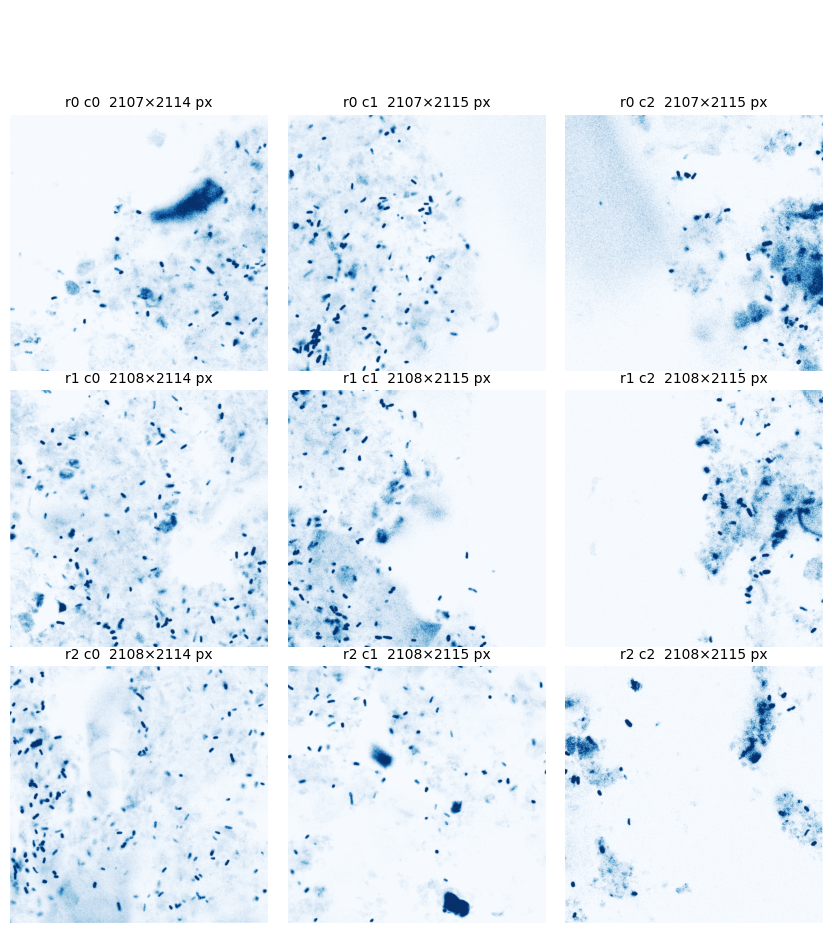

Saved → /Users/alicehong/projects/cellpose-biosensor/figures/qc/01_04222026/01_patches_preview.svg


In [40]:
fig, axes = plt.subplots(N_ROWS, N_COLS,
                          figsize=(N_COLS * 3.5, N_ROWS * 3.5),
                          facecolor='white')
fig.subplots_adjust(hspace=0.075, wspace=0.075)

for p in patches:
    ax = axes[p['row']][p['col']]
    img_norm = normalize_for_segmentation(
        p['tile'].astype(np.uint16),
        low_pct=NORM_LOW_PCT, high_pct=NORM_HIGH_PCT)
    ax.imshow(img_norm, cmap='Blues', vmin=0, vmax=1)
    ax.set_title(f"r{p['row']} c{p['col']}  {p['h']}×{p['w']} px",
                 color='black', fontsize=10)
    ax.axis('off')

fig.suptitle(f'BFP — {N_ROWS}×{N_COLS} patches (p{NORM_LOW_PCT}–p{NORM_HIGH_PCT} norm)',
             color='white', fontsize=10)
plt.savefig(FIG_DIR / '01_patches_preview.svg', dpi=100,
            bbox_inches='tight', facecolor='white')
plt.show()
print(f'Saved → {FIG_DIR}/01_patches_preview.svg')

## Spatial map — patch boundaries on full-image thumbnail

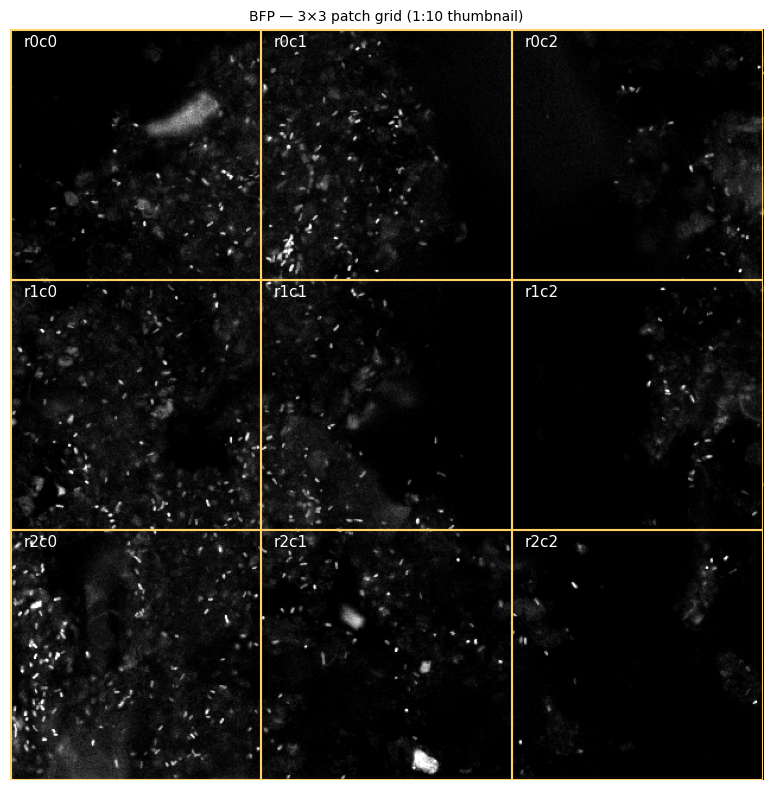

Saved → /Users/alicehong/projects/cellpose-biosensor/figures/qc/01_04222026/01_patch_map.svg


In [44]:
THUMB = 10
thumb = stack[0][::THUMB, ::THUMB]
thumb_norm = normalize_for_segmentation(
    thumb.astype(np.uint16), low_pct=1, high_pct=99.9)

fig, ax = plt.subplots(figsize=(8, 8), facecolor='white')
ax.set_facecolor('white')
ax.imshow(thumb_norm, cmap='gray', vmin=0, vmax=1)

for p in patches:
    rect = mpatches.Rectangle(
        (p['x0'] / THUMB, p['y0'] / THUMB),
        p['w'] / THUMB, p['h'] / THUMB,
        linewidth=1.5, edgecolor='#ffd166', facecolor='none')
    ax.add_patch(rect)
    ax.text(p['x0'] / THUMB + (p['w'] / THUMB) * 0.05,
            p['y0'] / THUMB + (p['h'] / THUMB) * 0.07,
            f"r{p['row']}c{p['col']}",
            color='white', fontsize=11)

ax.set_title(f'BFP — {N_ROWS}×{N_COLS} patch grid (1:{THUMB} thumbnail)',
             color='black', fontsize=10)
ax.axis('off')
plt.tight_layout()
plt.savefig(FIG_DIR / '01_patch_map.svg', dpi=120,
            bbox_inches='tight', facecolor='white')
plt.show()
print(f'Saved → {FIG_DIR}/01_patch_map.svg')

## Save patches to data/annotations/images/

Saved as **raw uint16** — same format as the original stack.
The Cellpose GUI normalises internally for display; `train_seg` normalises
internally for training. No pre-processing needed here.

Filename: `patch_r{row}_c{col}.tif`

In [31]:
for p in patches:
    fname = ANNOT_DIR / f"patch_r{p['row']}_c{p['col']}.tif"
    tifffile.imwrite(str(fname), p['tile'].astype(np.uint16),
                     compression='lzw', photometric='minisblack')
    print(f'  {fname.name}  ({p["h"]}×{p["w"]} px  uint16)')

print(f'\nSaved {len(patches)} patches to {ANNOT_DIR}')

  patch_r0_c0.tif  (2107×2114 px  uint16)
  patch_r0_c1.tif  (2107×2115 px  uint16)
  patch_r0_c2.tif  (2107×2115 px  uint16)
  patch_r1_c0.tif  (2108×2114 px  uint16)
  patch_r1_c1.tif  (2108×2115 px  uint16)
  patch_r1_c2.tif  (2108×2115 px  uint16)
  patch_r2_c0.tif  (2108×2114 px  uint16)
  patch_r2_c1.tif  (2108×2115 px  uint16)
  patch_r2_c2.tif  (2108×2115 px  uint16)

Saved 9 patches to /Users/alicehong/projects/cellpose-biosensor/data/annotations/images
